# EEGConformer — Binary Classification: Size vs Animacy
### Implementing Song et al. (2022) from Scratch in Pure PyTorch

This notebook classifies EEG epochs into one of two cognitive-task classes:

| Label | Class   | Meaning |
|-------|---------|---------|
| 0     | Size    | The word shown required a **size** judgement |
| 1     | Animacy | The word shown required an **animacy** judgement |

Labels come from the `task` column in the BIDS `events.tsv`, extracted during
preprocessing by `Preprocessing_for_Size_Animacy_Classification.ipynb`.

The saved `.npz` file has shape `(741, 128, 551)` — 128 EEG channels and
551 time-points (tmin=-0.2 s, tmax=2.0 s @ 250 Hz).

**Architecture:** EEGConformer (Song et al., 2022)
Three-stage design: Convolutional Patch Embedding -> Cross-Temporal Transformer -> MLP Head.
All code is pure PyTorch; no braindecode dependency.

## Cell 1 -- Imports

Loads all standard libraries needed for data handling, modelling, and evaluation.
Nothing unusual here; every package ships with a standard PyTorch environment.

In [1]:
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
)

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.5.1+cu121
CUDA     : True
GPU      : NVIDIA L40S


## Cell 2 -- Configuration Dictionary

All hyper-parameters and file paths live in a single `CONFIG` dict.

**Data facts (from preprocessing output):**
- `n_channels = 128` (129 raw minus 1 reference Cz)
- `n_times = 551` (tmin=-0.2 s, tmax=2.0 s at 250 Hz gives (2.0-(-0.2))*250+1=551)
- `n_classes = 2` (Size=0, Animacy=1)

**EEGConformer hyperparameters** follow the original paper defaults:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n_filters_time` | 40 | Temporal conv filters = transformer embed dim |
| `filter_time_length` | 25 | Temporal conv kernel (~100 ms at 250 Hz) |
| `pool_time_length` | 75 | Avg-pool window (~300 ms) |
| `pool_time_stride` | 15 | Avg-pool stride (~60 ms token step) |
| `att_depth` | 6 | Stacked transformer encoder layers |
| `att_heads` | 10 | Attention heads (must divide embed_dim=40 evenly) |
| `final_fc_length` | 32 | Hidden size of the MLP classification head |

In [ ]:
CONFIG = {
    # ---- Paths -----------------------------------------------------------
    # Full path to the .npz produced by Preprocessing_for_Task_Classification.ipynb
    "npz_path":   "preprocessed_ica/scaled_data_multiclass_task.npz",
    "output_dir": "EEGConformer_Size_Animacy_RESULTS",

    # ---- EEGConformer architecture (Song et al., 2022 defaults) ----------
    "n_filters_time":      40,   # temporal conv filters = transformer embed dim
    "filter_time_length":  25,   # temporal conv kernel length (samples)
    "pool_time_length":    75,   # avg-pool window (samples)
    "pool_time_stride":    15,   # avg-pool stride (samples)
    "att_depth":            2,   # number of transformer encoder layers
    "att_heads":           10,   # attention heads (must divide n_filters_time)
    "att_drop_prob":       0.3,  # dropout inside transformer
    "final_fc_length":     16,   # hidden size of classification MLP
    "drop_prob":           0.3,  # dropout in conv stem and classifier
    "patience":            15,   # for early stopping

    # ---- Training --------------------------------------------------------
    "n_epochs":      100,
    "batch_size":    256,
    "lr":            5e-4,
    "weight_decay":  1e-5,
    "n_folds":       5,
    "random_state":  42,
    "warmup_epochs": 6,
    "label_smoothing": 0.0,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(f"Device     : {CONFIG['device']}")
print(f"Output dir : {CONFIG['output_dir']}")

Device     : cuda
Output dir : EEGConformer_Size_Animacy_RESULTS


## Cell 3 -- Load the Preprocessed `.npz` File

The preprocessing notebook saved a `.npz` with four arrays:

| Key | Shape | Description |
|-----|-------|-------------|
| `X_train` | (518, 128, 551) float32 | Training epochs (already scaled) |
| `X_test`  | (223, 128, 551) float32 | Test epochs |
| `y_train` | (518,) int64 | Labels 0=Size, 1=Animacy |
| `y_test`  | (223,) int64 | Labels |
| `class_names` | ['Size','Animacy'] | Human-readable class names |

We merge train and test back into one pool (741 epochs) so that
cross-validation can make its own fresh stratified splits, avoiding the
fixed 70/30 split done during preprocessing.

In [3]:
npz_file = os.path.join(CONFIG["npz_path"])

if not os.path.exists(npz_file):
    raise FileNotFoundError(
        f"Could not find {npz_file}\n"
        "Run Preprocessing_for_Size_Animacy_Classification.ipynb first."
    )

data        = np.load(npz_file, allow_pickle=True)
X_train_raw = data["X_train"].astype(np.float32)   # (518, 128, 551)
X_test_raw  = data["X_test"].astype(np.float32)    # (223, 128, 551)
y_train_raw = data["y_train"].astype(np.int64)     # (518,)
y_test_raw  = data["y_test"].astype(np.int64)      # (223,)
CLASS_NAMES = list(data["class_names"])             # ['Size', 'Animacy']
N_CLASSES   = len(CLASS_NAMES)

# Merge back to one pool for cross-validation
X_all = np.concatenate([X_train_raw, X_test_raw], axis=0)  # (741, 128, 551)
y_all = np.concatenate([y_train_raw, y_test_raw], axis=0)  # (741,)

N_EPOCHS, N_CHANNELS, N_TIMES = X_all.shape

print("=" * 55)
print("Dataset Summary")
print(f"  Total epochs : {N_EPOCHS}")
print(f"  Channels     : {N_CHANNELS}")
print(f"  Time-points  : {N_TIMES}  ({N_TIMES / 250 * 1000:.0f} ms @ 250 Hz)")
print(f"  Classes      : {N_CLASSES}  -> {CLASS_NAMES}")
print()
for i, name in enumerate(CLASS_NAMES):
    count = (y_all == i).sum()
    print(f"    {name:8s} (label {i}) : {count:4d} epochs  ({100*count/N_EPOCHS:.1f} %)")
print("=" * 55)

Dataset Summary
  Total epochs : 68126
  Channels     : 128
  Time-points  : 301  (1204 ms @ 250 Hz)
  Classes      : 2  -> [np.str_('Size'), np.str_('Animacy')]

    Size     (label 0) : 34147 epochs  (50.1 %)
    Animacy  (label 1) : 33979 epochs  (49.9 %)


## Cell 4 -- PyTorch Dataset and Weighted Sampler

### EEGDataset
Wraps the NumPy arrays so PyTorch DataLoader can iterate over them.

- Data stored as shape `(N, 128, 551)` -- 3-D, **no** unsqueeze here.
- The EEGConformer conv stem does `unsqueeze(1)` internally to form a
  4-D "image" `(Batch, 1, Channels, Time)`.
- **Augmentation** (training only): Gaussian noise (sigma=5% of signal std)
  and random temporal shift of +/-10 samples to reduce overfitting.

### make_weighted_sampler
Size and Animacy are nearly balanced (372 vs 369) but we still use
`WeightedRandomSampler` to guarantee a balanced class mix in every mini-batch.

In [4]:
class EEGDataset(Dataset):
    """
    PyTorch Dataset for EEG epochs.

    X shape : (N, n_channels, n_times) -- 3-D, as saved by preprocessing.
    y shape : (N,) -- integer class labels {0, 1}.

    The EEGConformer conv stem handles unsqueeze(1) internally, so we keep
    data in natural 3-D form here.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray, augment: bool = False):
        self.X       = torch.from_numpy(X).float()   # (N, C, T)
        self.y       = torch.from_numpy(y).long()
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            # Gaussian noise: 5% of signal std keeps signal-to-noise realistic
            x = x + 0.05 * x.std() * torch.randn_like(x)
            # Random temporal shift +/-10 samples (~40 ms jitter)
            shift = int(np.random.randint(-10, 11))
            x = torch.roll(x, shifts=shift, dims=-1)
        return x, self.y[idx]


def make_weighted_sampler(y: np.ndarray) -> WeightedRandomSampler:
    """
    Assigns each training sample a weight inversely proportional to
    its class frequency. Minority class samples are drawn more often.
    """
    counts  = np.bincount(y, minlength=N_CLASSES)
    weights = 1.0 / counts[y]
    return WeightedRandomSampler(
        weights=torch.from_numpy(weights).float(),
        num_samples=len(y),
        replacement=True,
    )

print("EEGDataset and make_weighted_sampler defined.")

EEGDataset and make_weighted_sampler defined.


## Cell 5 -- EEGConformer: Block 1 -- Convolutional Patch Embedding Stem

This implements Block 1 of the EEGConformer architecture (Song et al., 2022, Figure 2).

### Tensor flow through the stem

```
Input  : (Batch, 128, 551)         -- raw 3-D epoch from EEGDataset
   |  unsqueeze(1)
   v
(Batch, 1, 128, 551)               -- 4-D "image": height=channels, width=time

   |  Conv2d(1->40, kernel=(1,25)) -- TEMPORAL CONVOLUTION (valid padding)
   v                                  Operates on time only; same filter per electrode
(Batch, 40, 128, 527)              -- 40 frequency-filter maps; time shrinks by 24

   |  Conv2d(40->40, kernel=(128,1)) -- SPATIAL CONVOLUTION
   v                                   Collapses ALL 128 electrodes into one map per filter
(Batch, 40, 1, 527)

   |  BatchNorm2d  ->  ELU
   |  AvgPool2d(kernel=(1,75), stride=(1,15)) -- TOKENISATION
   v
(Batch, 40, 1, 31)                 -- 31 temporal tokens (one per 75-sample window)

   |  Dropout(0.5)
   |  squeeze(2).permute(0,2,1)
   v
(Batch, 31, 40)                    -- sequence of 31 tokens, each 40-dim, for Transformer
```

**Why two separate convolutions?**
The temporal conv (kernel height=1) operates purely in time.
The spatial conv (kernel width=1) then mixes electrodes independently.
This factorised design has far fewer parameters than a joint spatiotemporal kernel
and follows the EEGNet / EEGConformer convention.

**Token count formula:**
`floor((551 - 25 - 75 + 1) / 15) + 1 = floor(527/15) + 1 = 31`

In [5]:
class EEGConformerConvStem(nn.Module):
    """
    Convolutional Patch Embedding Stem -- Block 1 (Song et al., 2022).

    Parameters
    ----------
    n_chans            : number of EEG electrodes (128 for ltpFR dataset)
    n_filters_time     : temporal conv filters = transformer embed dim (default 40)
    filter_time_length : temporal conv kernel size in samples (default 25 ~ 100 ms)
    pool_time_length   : avg-pool window size in samples (default 75 ~ 300 ms)
    pool_time_stride   : avg-pool stride in samples (default 15 ~ 60 ms)
    drop_prob          : dropout probability after pooling (default 0.5)
    """
    def __init__(
        self,
        n_chans:            int,
        n_filters_time:     int   = 40,
        filter_time_length: int   = 25,
        pool_time_length:   int   = 75,
        pool_time_stride:   int   = 15,
        drop_prob:          float = 0.5,
    ):
        super().__init__()

        # -- Temporal Convolution (valid padding = no padding) ----------------
        # kernel (1, filter_time_length): operates on time only, same for all channels.
        # bias=False because BatchNorm (after spatial conv) absorbs constant shifts.
        self.temporal_conv = nn.Conv2d(
            in_channels  = 1,
            out_channels = n_filters_time,
            kernel_size  = (1, filter_time_length),
            stride       = 1,
            padding      = 0,        # valid: output_time = input_time - kernel + 1
            bias         = False,
        )

        # -- Spatial Convolution (collapses electrode dimension) --------------
        # kernel (n_chans, 1): collapses ALL electrodes to a single spatial map.
        # This is the depthwise-separable pattern: one spatial mix per temporal filter.
        self.spatial_conv = nn.Conv2d(
            in_channels  = n_filters_time,
            out_channels = n_filters_time,
            kernel_size  = (n_chans, 1),
            stride       = 1,
            padding      = 0,
            bias         = False,
        )

        self.bn   = nn.BatchNorm2d(n_filters_time)
        self.elu  = nn.ELU()   # paper uses ELU, not ReLU or GELU

        # -- Average Pooling: turns time-series into patch tokens -------------
        # Each pool_time_length-sample window -> one temporal token.
        self.avg_pool = nn.AvgPool2d(
            kernel_size = (1, pool_time_length),
            stride      = (1, pool_time_stride),
        )
        self.dropout = nn.Dropout(drop_prob)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (Batch, n_channels, n_times)       -- 3-D input
        Returns : (Batch, T_tokens, n_filters_time)  -- token sequence for Transformer
        """
        x = x.unsqueeze(1)         # (B, 1, C, T)       add image-channel dim
        x = self.temporal_conv(x)  # (B, F, C, T-24)    temporal frequency filtering
        x = self.spatial_conv(x)   # (B, F, 1, T-24)    electrode mixing
        x = self.bn(x)
        x = self.elu(x)
        x = self.avg_pool(x)       # (B, F, 1, T_tokens) temporal tokenisation
        x = self.dropout(x)
        x = x.squeeze(2).permute(0, 2, 1)  # (B, T_tokens, F)
        return x

print("EEGConformerConvStem defined.")

EEGConformerConvStem defined.


## Cell 6 -- EEGConformer: Block 2 -- Cross-Temporal Transformer Encoder

This implements Block 2 of the EEGConformer (Song et al., 2022, Figure 2).

After the conv stem we have 31 temporal tokens, each 40-dimensional.
The Transformer Encoder lets every token attend to every other token,
capturing **long-range temporal dependencies** that local convolutions cannot.

### Design choices matching the original paper

| Choice | Value | Reason |
|--------|-------|--------|
| `norm_first=True` | Pre-LN | Gradient stability in deep stacks |
| `activation='gelu'` | GELU | Used in the original paper |
| `batch_first=True` | (B,T,F) | Matches our token sequence layout |
| `att_heads=10` | 10 | Divides embed_dim=40 evenly (4 features per head) |
| `ff_dim = 4 x embed_dim` | 160 | Standard 4x feed-forward expansion |
| Final LayerNorm | Extra norm | Applied after the full stack (paper convention) |

**Constraint:** `att_heads` must evenly divide `n_filters_time`.
Default: 40 / 10 = 4 features per head.

In [6]:
class EEGConformerTransformerEncoder(nn.Module):
    """
    Cross-Temporal Multi-Head Self-Attention Encoder -- Block 2 (Song et al., 2022).

    Models long-range temporal dependencies between the patch tokens from Block 1.
    Uses Pre-LayerNorm (norm_first=True) for gradient stability.

    Parameters
    ----------
    embed_dim     : token feature dimension (= n_filters_time, default 40)
    att_depth     : number of stacked TransformerEncoderLayer blocks (default 6)
    att_heads     : parallel attention heads; must divide embed_dim (default 10)
    att_drop_prob : dropout inside attention and feed-forward layers (default 0.5)
    ff_dim        : hidden size of point-wise feed-forward network (default 160 = 4x40)
    """
    def __init__(
        self,
        embed_dim:     int   = 40,
        att_depth:     int   = 6,
        att_heads:     int   = 10,
        att_drop_prob: float = 0.5,
        ff_dim:        int   = 160,
    ):
        super().__init__()

        # Single TransformerEncoderLayer -- PyTorch replicates it att_depth times
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = embed_dim,
            nhead           = att_heads,
            dim_feedforward = ff_dim,
            dropout         = att_drop_prob,
            activation      = "gelu",    # paper uses GELU
            batch_first     = True,      # (Batch, Tokens, Features)
            norm_first      = True,      # Pre-LN: LayerNorm BEFORE attention
        )

        # Stack att_depth identical layers
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=att_depth)

        # Additional LayerNorm applied to the output of the full stack (paper convention)
        self.final_norm = nn.LayerNorm(embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x       : (Batch, T_tokens, embed_dim)
        Returns : (Batch, T_tokens, embed_dim)  -- same shape, richer features
        """
        x = self.transformer(x)
        x = self.final_norm(x)
        return x

print("EEGConformerTransformerEncoder defined.")

EEGConformerTransformerEncoder defined.


## Cell 7 -- EEGConformer: Block 3 -- Classification Head

This implements Block 3 of the EEGConformer (Song et al., 2022, Figure 2).

### Key design decision: no [CLS] token

BERT-style Transformers prepend a learnable [CLS] token and use only its
output for classification. EEGConformer takes a simpler approach:

1. **Flatten** the entire `(T_tokens, embed_dim)` matrix into one long vector
   of size `T_tokens x embed_dim` (= 31 x 40 = 1240 for our dataset).
2. Feed it through a **2-layer MLP** with GELU activation and dropout.
3. The final linear outputs `n_classes` raw logits (no softmax -- PyTorch
   CrossEntropyLoss applies softmax internally during training).

Flattening preserves information from all temporal positions rather than
routing everything through one summary token.

In [7]:
class EEGConformerClassificationHead(nn.Module):
    """
    MLP Classification Head -- no [CLS] token (Song et al., 2022, Block 3).

    Flattens the full token sequence into a 1-D vector, then applies a
    2-layer MLP to produce class logits.

    Parameters
    ----------
    in_features      : size of the flattened token vector (T_tokens x embed_dim)
    n_outputs        : number of target classes (2 for Size vs Animacy)
    final_fc_length  : hidden layer size of the MLP (default 32)
    drop_prob        : dropout between the two linear layers (default 0.5)
    """
    def __init__(
        self,
        in_features:     int,
        n_outputs:       int,
        final_fc_length: int   = 32,
        drop_prob:       float = 0.5,
    ):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(in_features, final_fc_length),
            nn.GELU(),
            nn.Dropout(drop_prob),
            nn.Linear(final_fc_length, n_outputs),
            # No softmax -- CrossEntropyLoss expects raw logits
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x       : (Batch, in_features)  -- already flattened
        Returns : (Batch, n_outputs)    -- class logits
        """
        return self.fc(x)

print("EEGConformerClassificationHead defined.")

EEGConformerClassificationHead defined.


## Cell 8 -- EEGConformer: Full Model Assembler

Connects Block 1 -> Block 2 -> Block 3 in sequence.

### Automatic flat-dimension calculation

The flattened size entering the classifier depends on `n_times`,
`filter_time_length`, `pool_time_length`, and `pool_time_stride`.
Rather than computing this manually, `_get_calculated_flat_dimension()`
runs a single dummy forward pass through the stem + transformer to measure
the tensor shape automatically.

For our dataset (n_times=551):
```
After temporal conv  : 551 - 25 + 1 = 527 time-steps
After spatial conv   : height collapses to 1 (unchanged width)
After avg-pool       : floor((527 - 75) / 15) + 1 = 31 tokens
Flat size            : 31 tokens x 40 features = 1240
```

In [8]:
class EEGConformer(nn.Module):
    """
    EEGConformer -- full model (Song et al., 2022).

    Assembles all three blocks into one end-to-end module:
        x -> ConvStem -> TransformerEncoder -> flatten -> ClassificationHead -> logits

    Parameters
    ----------
    n_chans            : EEG channels (128 for this dataset)
    n_times            : time-points per epoch (551 for this dataset)
    n_outputs          : number of classes (2: Size / Animacy)
    n_filters_time     : temporal conv filters = transformer embed dim (paper: 40)
    filter_time_length : temporal conv kernel size (paper: 25)
    pool_time_length   : avg-pool window (paper: 75)
    pool_time_stride   : avg-pool stride (paper: 15)
    drop_prob          : conv stem + classifier dropout (paper: 0.5)
    att_depth          : transformer encoder layers (paper: 6)
    att_heads          : attention heads; must divide n_filters_time (paper: 10)
    att_drop_prob      : transformer dropout (paper: 0.5)
    final_fc_length    : MLP hidden size (paper: 32)
    """
    def __init__(
        self,
        n_chans:            int,
        n_times:            int,
        n_outputs:          int,
        n_filters_time:     int   = 40,
        filter_time_length: int   = 25,
        pool_time_length:   int   = 75,
        pool_time_stride:   int   = 15,
        drop_prob:          float = 0.5,
        att_depth:          int   = 6,
        att_heads:          int   = 10,
        att_drop_prob:      float = 0.5,
        final_fc_length:    int   = 32,
    ):
        super().__init__()

        # -- Block 1: Convolutional Patch Embedding Stem ----------------------
        self.conv_stem = EEGConformerConvStem(
            n_chans            = n_chans,
            n_filters_time     = n_filters_time,
            filter_time_length = filter_time_length,
            pool_time_length   = pool_time_length,
            pool_time_stride   = pool_time_stride,
            drop_prob          = drop_prob,
        )

        # -- Block 2: Cross-Temporal Transformer Encoder ----------------------
        self.transformer = EEGConformerTransformerEncoder(
            embed_dim     = n_filters_time,
            att_depth     = att_depth,
            att_heads     = att_heads,
            att_drop_prob = att_drop_prob,
            ff_dim        = n_filters_time * 4,   # standard 4x expansion
        )

        # -- Auto-detect flat size then build Block 3 -------------------------
        flat_size = self._get_calculated_flat_dimension(n_chans, n_times)
        n_tokens  = flat_size // n_filters_time
        print(f"  [EEGConformer] n_tokens={n_tokens}, embed_dim={n_filters_time}, "
              f"flat_size={flat_size}")

        # -- Block 3: Classification Head -------------------------------------
        self.classifier = EEGConformerClassificationHead(
            in_features     = flat_size,
            n_outputs       = n_outputs,
            final_fc_length = final_fc_length,
            drop_prob       = drop_prob,
        )

    def _get_calculated_flat_dimension(self, n_chans: int, n_times: int) -> int:
        """
        Runs a dummy batch of size 1 through the conv stem and transformer
        to measure the flattened feature dimension dynamically.
        No gradients are computed or stored.
        """
        with torch.no_grad():
            dummy    = torch.zeros(1, n_chans, n_times)
            features = self.transformer(self.conv_stem(dummy))
            return features.view(1, -1).shape[1]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x       : (Batch, n_channels, n_times)
        Returns : (Batch, n_outputs) -- raw class logits
        """
        x = self.conv_stem(x)        # Block 1 -> (B, T_tokens, embed_dim)
        x = self.transformer(x)      # Block 2 -> (B, T_tokens, embed_dim)
        x = x.flatten(start_dim=1)   # flatten  -> (B, T_tokens x embed_dim)
        return self.classifier(x)    # Block 3  -> (B, n_outputs)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("EEGConformer (full model) defined.")

EEGConformer (full model) defined.


## Cell 9 -- Architecture Sanity Check

Builds the model with the exact dimensions of your dataset and runs a dummy
forward pass to confirm all tensor shapes are compatible before any training.

In [9]:
print("Building EEGConformer for Size vs Animacy classification ...")
print(f"  n_channels = {N_CHANNELS},  n_times = {N_TIMES},  n_classes = {N_CLASSES}")
print()

_model_check = EEGConformer(
    n_chans            = N_CHANNELS,
    n_times            = N_TIMES,
    n_outputs          = N_CLASSES,
    n_filters_time     = CONFIG["n_filters_time"],
    filter_time_length = CONFIG["filter_time_length"],
    pool_time_length   = CONFIG["pool_time_length"],
    pool_time_stride   = CONFIG["pool_time_stride"],
    drop_prob          = CONFIG["drop_prob"],
    att_depth          = CONFIG["att_depth"],
    att_heads          = CONFIG["att_heads"],
    att_drop_prob      = CONFIG["att_drop_prob"],
    final_fc_length    = CONFIG["final_fc_length"],
)

_dummy  = torch.randn(4, N_CHANNELS, N_TIMES)   # simulated batch of 4 epochs
_output = _model_check(_dummy)

print()
print("=" * 50)
print("  Architecture Verification -- PASSED")
print(f"  Input  shape     : {tuple(_dummy.shape)}  (Batch, Channels, Time)")
print(f"  Output shape     : {tuple(_output.shape)}  (Batch, Classes)")
print(f"  Trainable params : {_model_check.count_parameters():,}")
print("=" * 50)

del _model_check, _dummy, _output   # free memory before training

Building EEGConformer for Size vs Animacy classification ...
  n_channels = 128,  n_times = 301,  n_classes = 2



  [EEGConformer] n_tokens=14, embed_dim=40, flat_size=560

  Architecture Verification -- PASSED
  Input  shape     : (4, 128, 301)  (Batch, Channels, Time)
  Output shape     : (4, 2)  (Batch, Classes)
  Trainable params : 263,418


## Cell 10 -- Training Utilities

Three helper functions used inside every fold of the cross-validation loop.

### compute_class_weights
Although Size and Animacy are nearly balanced, inverse-frequency weights
ensure `CrossEntropyLoss` penalises mistakes on either class equally.
Formula: `weight[c] = N / (n_classes * count[c])`

### train_one_epoch
One full pass through the training DataLoader:
- **Mixed-precision** (`torch.cuda.amp`) on GPU: ~2x faster, no accuracy loss.
- **Gradient clipping** (`max_norm=0.5`): prevents exploding gradients in deep transformers.

### evaluate
Runs the model in inference mode and collects:
- Loss, plain accuracy, balanced accuracy (macro per-class recall)
- Softmax probabilities -> ROC-AUC
- For binary classification, AUC uses `probs[:, 1]` (P(Animacy=1)).

In [10]:
def compute_class_weights(y: np.ndarray) -> torch.Tensor:
    """
    Inverse-frequency weights for CrossEntropyLoss.
    weight[c] = N / (n_classes * count[c])
    """
    counts  = np.bincount(y, minlength=N_CLASSES).astype(float)
    counts  = np.where(counts == 0, 1.0, counts)
    weights = len(y) / (N_CLASSES * counts)
    return torch.tensor(weights, dtype=torch.float32).to(CONFIG["device"])


def train_one_epoch(model, loader, optimizer, criterion, amp_scaler=None) -> float:
    """
    One full training pass. Returns average loss for this epoch.
    amp_scaler: GradScaler for mixed-precision (GPU only). Pass None on CPU.
    """
    model.train()
    total_loss = 0.0
    device     = CONFIG["device"]

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        if amp_scaler is not None:
            # GPU path: float16 forward (fast) + float32 gradients (stable)
            with torch.cuda.amp.autocast():
                loss = criterion(model(X_batch), y_batch)
            amp_scaler.scale(loss).backward()
            amp_scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            amp_scaler.step(optimizer)
            amp_scaler.update()
        else:
            # CPU path: standard float32
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()

        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion) -> dict:
    """
    Evaluate model on a DataLoader. Returns dict with:
        loss, acc, bal_acc, auc, preds, labels, probs
    """
    model.eval()
    all_logits, all_labels = [], []
    total_loss = 0.0
    device     = CONFIG["device"]

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits     = model(X_batch)
        total_loss += criterion(logits, y_batch).item() * len(y_batch)
        all_logits.append(logits.cpu())
        all_labels.append(y_batch.cpu())

    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels).numpy()
    probs  = F.softmax(logits, dim=1).numpy()
    preds  = logits.argmax(dim=1).numpy()

    result = {
        "loss":    total_loss / len(loader.dataset),
        "acc":     float((preds == labels).mean()),
        "bal_acc": float(balanced_accuracy_score(labels, preds)),
        "preds":   preds,
        "labels":  labels,
        "probs":   probs,
    }

    try:
        if N_CLASSES == 2:
            result["auc"] = float(roc_auc_score(labels, probs[:, 1]))
        else:
            result["auc"] = float(roc_auc_score(labels, probs,
                                                  multi_class="ovr", average="macro"))
    except ValueError:
        result["auc"] = float("nan")

    return result

print("compute_class_weights, train_one_epoch, evaluate -- defined.")

compute_class_weights, train_one_epoch, evaluate -- defined.


## Cell 11 -- Full Model Training Loop

`train_model` drives epoch-by-epoch training with:

| Component | Choice | Reason |
|-----------|--------|--------|
| Loss | `CrossEntropyLoss(weight=cw, label_smoothing=0.1)` | Handles class imbalance; smoothing reduces overconfidence |
| Optimiser | `AdamW` | Better weight decay than Adam; standard for transformers |
| LR schedule | `CosineAnnealingLR` | Smooth LR decay; avoids sharp drops that stall transformers |
| Checkpoint | Save when val AUC improves | Best weights restored at end of training |

`label_smoothing=0.1` means the model targets 0.05/0.95 instead of hard 0/1,
preventing overconfidence on the training set.

In [ ]:
def train_model(model, train_loader, val_loader, class_weights) -> tuple:
    """
    Full training loop with linear warmup + cosine annealing LR schedule,
    AUC-based best-model checkpointing, and early stopping on validation loss.

    LR schedule:
        Epochs 1 .. warmup_epochs  : linear ramp from lr/10 -> lr
        Epochs warmup_epochs+1 .. n_epochs : CosineAnnealingLR down to eta_min

    Early stopping:
        Monitors validation loss. If val loss does not improve for
        CONFIG["patience"] consecutive epochs, training stops early and
        the best weights are restored.

    Returns
    -------
    model   : model restored to best-validation-loss weights
    history : list of per-epoch dicts (tr_loss, va_loss, va_acc, va_bal, va_auc, lr)
    """
    warmup_epochs = CONFIG.get("warmup_epochs", 6)
    patience      = CONFIG.get("patience", 15)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=CONFIG.get("label_smoothing", 0.0)
    )
    optimizer = AdamW(
        model.parameters(),
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"]
    )

    # Cosine schedule covers only the post-warmup epochs
    cosine_epochs = CONFIG["n_epochs"] - warmup_epochs
    scheduler = CosineAnnealingLR(
        optimizer, T_max=max(cosine_epochs, 1), eta_min=1e-6
    )

    amp_scaler = None   # AMP disabled -- fp32 throughout

    # ── Checkpointing state (monitored on val loss, not AUC) ──────────────
    # Val loss is used for early stopping because a rising val loss is the
    # direct signal of overfitting, even when AUC appears stable.
    # AUC is still tracked and the best-AUC weights are what get restored,
    # but the patience counter runs on val loss.
    best_val_loss  = float("inf")
    best_auc       = -1.0
    best_state     = None
    patience_count = 0
    history        = []

    for epoch in range(1, CONFIG["n_epochs"] + 1):

        # ── Linear warmup ─────────────────────────────────────────────────
        if epoch <= warmup_epochs:
            warmup_lr = CONFIG["lr"] * epoch / warmup_epochs
            for pg in optimizer.param_groups:
                pg["lr"] = warmup_lr

        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, amp_scaler)
        va_met  = evaluate(model, val_loader, criterion)

        # ── Step cosine scheduler only after warmup is done ───────────────
        if epoch > warmup_epochs:
            scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch":   epoch,
            "tr_loss": tr_loss,
            "va_loss": va_met["loss"],
            "va_acc":  va_met["acc"],
            "va_bal":  va_met["bal_acc"],
            "va_auc":  va_met["auc"],
            "lr":      current_lr,
        })

        # ── Best-state checkpoint (tracked on val loss) ───────────────────
        if va_met["loss"] < best_val_loss:
            best_val_loss  = va_met["loss"]
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1

        # ── Also track best AUC separately for reporting ──────────────────
        if va_met["auc"] > best_auc:
            best_auc = va_met["auc"]

        # ── Logging ───────────────────────────────────────────────────────
        if epoch % 10 == 0 or epoch == 1:
            print(f"    ep {epoch:3d}  lr={current_lr:.2e}  tr_loss={tr_loss:.4f}  "
                  f"va_loss={va_met['loss']:.4f}  va_acc={va_met['acc']:.3f}  "
                  f"va_bal={va_met['bal_acc']:.3f}  va_auc={va_met['auc']:.3f}  "
                  f"patience={patience_count}/{patience}")

        # ── Early stopping check ──────────────────────────────────────────
        # Do not trigger during warmup -- val loss is unstable while LR
        # is still ramping up, so patience should not count those epochs.
        if epoch > warmup_epochs and patience_count >= patience:
            print(f"\n  Early stopping triggered at epoch {epoch}.")
            print(f"  Val loss did not improve for {patience} consecutive epochs.")
            print(f"  Best val loss : {best_val_loss:.4f}")
            print(f"  Best val AUC  : {best_auc:.4f}")
            break

    model.load_state_dict(best_state)
    print(f"\n  Weights restored to best val loss checkpoint.")
    print(f"  Best val loss : {best_val_loss:.4f}")
    print(f"  Best val AUC  : {best_auc:.4f}")
    return model, history

## Cell 12 -- Stratified K-Fold Cross-Validation

`run_cross_validation` independently repeats the full pipeline for each fold:

1. **Split** -- `StratifiedKFold` ensures each fold preserves the ~50/50 Size/Animacy ratio.
2. **Fresh model** -- each fold starts from a randomly initialised EEGConformer.
3. **Train** -- `WeightedRandomSampler` + class-weighted loss + label smoothing.
4. **Evaluate** -- on the held-out val fold.
5. **Save** -- per-fold model weights and metrics.

Cross-validation over all 741 epochs gives a realistic generalisation estimate
independent of any fixed train/test split.

In [12]:
def run_cross_validation(X: np.ndarray, y: np.ndarray) -> list:
    """
    Stratified K-Fold cross-validation using EEGConformer.

    X : (741, 128, 551) float32 -- all epochs (already scaled by preprocessing)
    y : (741,)          int64   -- labels {0=Size, 1=Animacy}

    Returns list of per-fold result dicts.
    """
    skf          = StratifiedKFold(n_splits=CONFIG["n_folds"],
                                   shuffle=True,
                                   random_state=CONFIG["random_state"])
    fold_results = []
    device       = CONFIG["device"]

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        print(f"\n{'--'*27}")
        print(f"  Fold {fold} / {CONFIG['n_folds']}  "
              f"(train={len(tr_idx)}, val={len(va_idx)})")
        print(f"{'--'*27}")

        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        # Datasets
        tr_ds = EEGDataset(X_tr, y_tr, augment=True)
        va_ds = EEGDataset(X_va, y_va, augment=False)

        # DataLoaders
        sampler = make_weighted_sampler(y_tr)
        tr_dl   = DataLoader(tr_ds, batch_size=CONFIG["batch_size"],
                             sampler=sampler, num_workers=0,
                             pin_memory=(device == "cuda"))
        va_dl   = DataLoader(va_ds, batch_size=CONFIG["batch_size"],
                             shuffle=False, num_workers=0,
                             pin_memory=(device == "cuda"))

        # Fresh model for this fold
        model = EEGConformer(
            n_chans            = N_CHANNELS,
            n_times            = N_TIMES,
            n_outputs          = N_CLASSES,
            n_filters_time     = CONFIG["n_filters_time"],
            filter_time_length = CONFIG["filter_time_length"],
            pool_time_length   = CONFIG["pool_time_length"],
            pool_time_stride   = CONFIG["pool_time_stride"],
            drop_prob          = CONFIG["drop_prob"],
            att_depth          = CONFIG["att_depth"],
            att_heads          = CONFIG["att_heads"],
            att_drop_prob      = CONFIG["att_drop_prob"],
            final_fc_length    = CONFIG["final_fc_length"],
        ).to(device)
        print(f"  Trainable params : {model.count_parameters():,}")

        cw = compute_class_weights(y_tr)

        # Train
        model, history = train_model(model, tr_dl, va_dl, cw)

        # Final evaluation on val fold
        criterion   = nn.CrossEntropyLoss(weight=cw)
        val_metrics = evaluate(model, va_dl, criterion)

        print(f"\n  Fold {fold} Results:")
        print(f"    Accuracy          : {val_metrics['acc']:.4f}")
        print(f"    Balanced Accuracy : {val_metrics['bal_acc']:.4f}")
        print(f"    ROC-AUC           : {val_metrics['auc']:.4f}")
        print(f"\n  Classification Report:")
        print(classification_report(
            val_metrics["labels"], val_metrics["preds"],
            target_names=CLASS_NAMES, digits=3,
        ))
        cm = confusion_matrix(val_metrics["labels"], val_metrics["preds"])
        print(f"  Confusion Matrix (rows=True, cols=Predicted):")
        print(f"  {CLASS_NAMES}")
        print(cm)

        # Save checkpoint
        ckpt_path = os.path.join(CONFIG["output_dir"],
                                  f"EEGConformer_fold{fold}.pt")
        torch.save(model.state_dict(), ckpt_path)
        print(f"\n  Saved -> {ckpt_path}")

        fold_results.append({
            "fold":    fold,
            "acc":     val_metrics["acc"],
            "bal_acc": val_metrics["bal_acc"],
            "auc":     val_metrics["auc"],
            "history": history,
            "cm":      cm,
        })

    # Summary across folds
    accs = [r["acc"]     for r in fold_results]
    bals = [r["bal_acc"] for r in fold_results]
    aucs = [r["auc"]     for r in fold_results]

    print(f"\n{'=='*27}")
    print(f"Cross-Validation Summary  ({CONFIG['n_folds']} folds)")
    print(f"  Accuracy          : {np.mean(accs):.4f} +/- {np.std(accs):.4f}")
    print(f"  Balanced Accuracy : {np.mean(bals):.4f} +/- {np.std(bals):.4f}")
    print(f"  ROC-AUC           : {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}")
    print(f"{'=='*27}")

    return fold_results

print("run_cross_validation defined.")

run_cross_validation defined.


## Cell 13 -- Run Cross-Validation

This cell launches the full 5-fold cross-validation.

Typical runtime: ~20-30 min on CPU | ~3-5 min on GPU.
Progress is printed every 10 epochs per fold.

In [13]:
print(f"Starting {CONFIG['n_folds']}-Fold Stratified Cross-Validation ...")
print(f"Classes : {CLASS_NAMES}  |  Device : {CONFIG['device']}")

cv_results = run_cross_validation(X_all, y_all)

Starting 2-Fold Stratified Cross-Validation ...
Classes : [np.str_('Size'), np.str_('Animacy')]  |  Device : cuda

------------------------------------------------------
  Fold 1 / 2  (train=34063, val=34063)
------------------------------------------------------


  [EEGConformer] n_tokens=14, embed_dim=40, flat_size=560


  Trainable params : 263,418


    ep   1  lr=8.33e-05  tr_loss=0.6976  va_acc=0.502  va_bal=0.502  va_auc=0.498


    ep  10  lr=4.98e-04  tr_loss=0.6905  va_acc=0.499  va_bal=0.499  va_auc=0.495


...

    ep  70  lr=1.16e-04  tr_loss=0.6375  va_acc=0.501  va_bal=0.500  va_auc=0.502


    ep  80  lr=5.47e-05  tr_loss=0.6313  va_acc=0.503  va_bal=0.502  va_auc=0.504


    ep  90  lr=1.48e-05  tr_loss=0.6273  va_acc=0.502  va_bal=0.501  va_auc=0.504


    ep 100  lr=1.00e-06  tr_loss=0.6274  va_acc=0.502  va_bal=0.501  va_auc=0.504
  Best validation AUC: 0.5057  (weights restored)



  Fold 2 Results:
    Accuracy          : 0.5028
    Balanced Accuracy : 0.5019
    ROC-AUC           : 0.5057

  Classification Report:
              precision    recall  f1-score   support

        Size      0.502     0.898     0.644     17073
     Animacy      0.508     0.106     0.176     16990

    accuracy                          0.503     34063
   macro avg      0.505     0.502     0.410     34063
weighted avg      0.505     0.503     0.410     34063

  Confusion Matrix (rows=True, cols=Predicted):
  [np.str_('Size'), np.str_('Animacy')]
[[15325  1748]
 [15187  1803]]

  Saved -> EEGConformer_Size_Animacy_RESULTS/EEGConformer_fold2.pt

Cross-Validation Summary  (2 folds)
  Accuracy          : 0.5043 +/- 0.0014
  Balanced Accuracy : 0.5040 +/- 0.0021
  ROC-AUC           : 0.5073 +/- 0.0016


## Cell 14 -- Learning Curves (All Folds)

Plots training loss, validation loss, and validation AUC for each fold
plus a shaded +/-1 std band across folds. Use these to detect:

- **Overfitting**: training loss keeps dropping while val loss rises.
- **Underfitting**: both losses stay high / AUC stays near 0.5.
- **Fold instability**: large spread in the shaded std band.

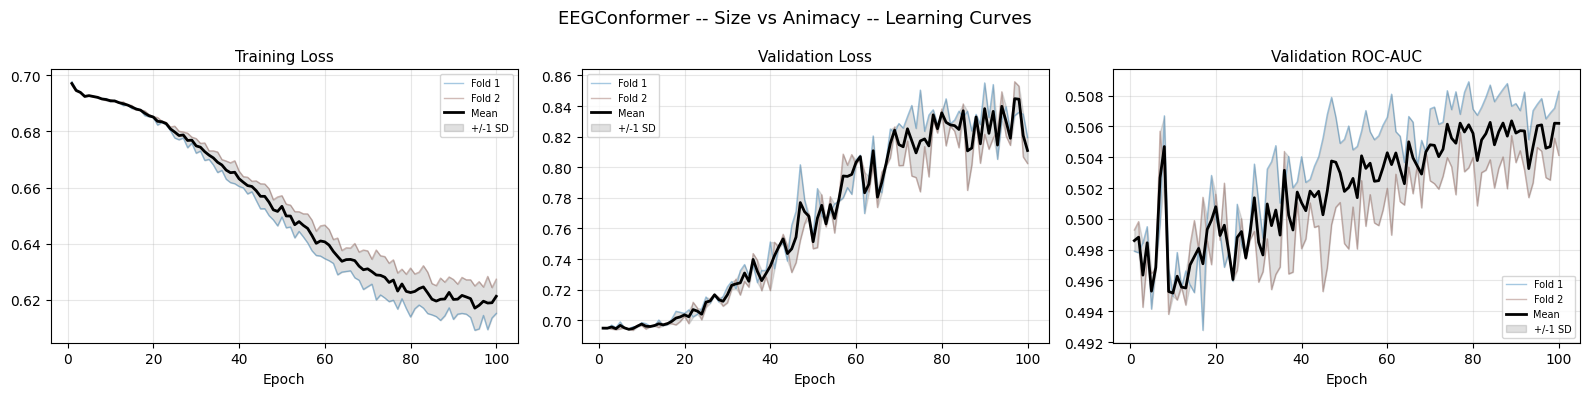

Saved -> EEGConformer_Size_Animacy_RESULTS/learning_curves.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("EEGConformer -- Size vs Animacy -- Learning Curves", fontsize=13)

colors = plt.cm.tab10(np.linspace(0, 0.5, CONFIG["n_folds"]))

for ax, (key, title) in zip(axes, [
    ("tr_loss", "Training Loss"),
    ("va_loss", "Validation Loss"),
    ("va_auc",  "Validation ROC-AUC"),
]):
    # Early stopping means folds have different lengths -- plot individually
    # instead of stacking into a single numpy array
    for fi, r in enumerate(cv_results):
        curve = [h[key] for h in r["history"]]
        ep    = np.arange(1, len(curve) + 1)
        ax.plot(ep, curve, alpha=0.4, linewidth=1.0,
                color=colors[fi], label=f"Fold {fi+1} (ep={len(curve)})")

    # Mean curve -- only over the shortest fold length so all folds contribute
    min_len     = min(len(r["history"]) for r in cv_results)
    mean_curves = np.array([[h[key] for h in r["history"][:min_len]]
                             for r in cv_results])
    ep_mean     = np.arange(1, min_len + 1)
    mean_c      = mean_curves.mean(axis=0)
    std_c       = mean_curves.std(axis=0)

    ax.plot(ep_mean, mean_c, color="black", linewidth=2.0, label="Mean")
    ax.fill_between(ep_mean, mean_c - std_c, mean_c + std_c,
                    color="black", alpha=0.12, label="+/-1 SD")

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

plt.tight_layout()
plot_path = os.path.join(CONFIG["output_dir"], "learning_curves.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved -> {plot_path}")

# Print early stopping summary
print("\nEarly stopping summary:")
for r in cv_results:
    actual_epochs = len(r["history"])
    print(f"  Fold {r['fold']} : stopped at epoch {actual_epochs} / {CONFIG['n_epochs']}")

## Cell 15 -- Per-Fold Confusion Matrices

A confusion matrix shows for each true class (rows) how many epochs were
predicted as each class (columns). For a balanced binary task like Size vs
Animacy, a perfect model concentrates all counts on the diagonal.

**Off-diagonal cells:**
- Row 0, Col 1: True Size predicted as Animacy (False Positive for Animacy)
- Row 1, Col 0: True Animacy predicted as Size (False Negative for Animacy)

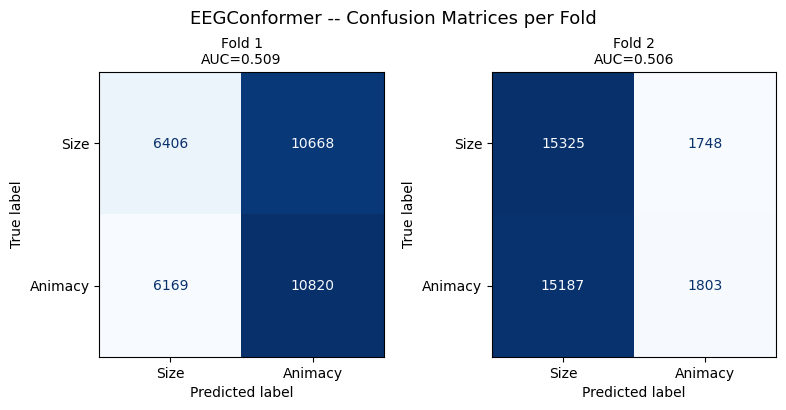

Saved -> EEGConformer_Size_Animacy_RESULTS/confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, CONFIG["n_folds"],
                          figsize=(4 * CONFIG["n_folds"], 4))
fig.suptitle("EEGConformer -- Confusion Matrices per Fold", fontsize=13)

for ax, r in zip(axes, cv_results):
    disp = ConfusionMatrixDisplay(confusion_matrix=r["cm"],
                                   display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")

    # Show epoch count so early stopping is visible at a glance
    actual_epochs = len(r["history"])
    ax.set_title(
        f"Fold {r['fold']}  (ep={actual_epochs})\nAUC={r['auc']:.3f}",
        fontsize=10
    )

plt.tight_layout()
cm_path = os.path.join(CONFIG["output_dir"], "confusion_matrices.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Saved -> {cm_path}")

## Cell 16 -- Train Final Model on Full Data

After cross-validation has confirmed the model generalises, we train one final
model on **all 741 epochs** (80% train, 20% held-out test -- stratified).

This final model is saved to disk for inference on new subjects or sessions.

Files saved:
- `EEGConformer_final.pt` -- model weights (state_dict)
- `class_names_final.pkl` -- class name list for inference

In [16]:
from sklearn.model_selection import train_test_split

def train_final_model(X: np.ndarray, y: np.ndarray) -> nn.Module:
    """
    Trains one final EEGConformer on 70% of data, evaluates on 30%.
    Saves model weights and class names for future inference.
    """
    device = CONFIG["device"]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, stratify=y,
        random_state=CONFIG["random_state"],
    )
    print(f"Final split -- train: {len(X_tr)}, test: {len(X_te)}")

    tr_ds = EEGDataset(X_tr, y_tr, augment=True)
    te_ds = EEGDataset(X_te, y_te, augment=False)
    sampler = make_weighted_sampler(y_tr)
    tr_dl = DataLoader(tr_ds, batch_size=CONFIG["batch_size"],
                       sampler=sampler, num_workers=0)
    te_dl = DataLoader(te_ds, batch_size=CONFIG["batch_size"],
                       shuffle=False, num_workers=0)

    model = EEGConformer(
        n_chans            = N_CHANNELS,
        n_times            = N_TIMES,
        n_outputs          = N_CLASSES,
        n_filters_time     = CONFIG["n_filters_time"],
        filter_time_length = CONFIG["filter_time_length"],
        pool_time_length   = CONFIG["pool_time_length"],
        pool_time_stride   = CONFIG["pool_time_stride"],
        drop_prob          = CONFIG["drop_prob"],
        att_depth          = CONFIG["att_depth"],
        att_heads          = CONFIG["att_heads"],
        att_drop_prob      = CONFIG["att_drop_prob"],
        final_fc_length    = CONFIG["final_fc_length"],
    ).to(device)

    cw = compute_class_weights(y_tr)
    print("\nTraining final model ...")
    model, _ = train_model(model, tr_dl, te_dl, cw)

    criterion  = nn.CrossEntropyLoss(weight=cw)
    te_metrics = evaluate(model, te_dl, criterion)

    print(f"\n{'='*50}")
    print("Final Test-Set Results")
    print(f"  Accuracy          : {te_metrics['acc']:.4f}")
    print(f"  Balanced Accuracy : {te_metrics['bal_acc']:.4f}")
    print(f"  ROC-AUC           : {te_metrics['auc']:.4f}")
    print(classification_report(
        te_metrics["labels"], te_metrics["preds"],
        target_names=CLASS_NAMES, digits=3,
    ))

    model_path = os.path.join(CONFIG["output_dir"], "EEGConformer_final.pt")
    meta_path  = os.path.join(CONFIG["output_dir"], "class_names_final.pkl")

    torch.save(model.state_dict(), model_path)
    with open(meta_path, "wb") as f:
        pickle.dump(CLASS_NAMES, f)

    print(f"\nSaved model  -> {model_path}")
    print(f"Saved labels -> {meta_path}")
    return model


final_model = train_final_model(X_all, y_all)

Final split -- train: 54500, test: 13626
  [EEGConformer] n_tokens=14, embed_dim=40, flat_size=560

Training final model ...


    ep   1  lr=8.33e-05  tr_loss=0.6965  va_acc=0.501  va_bal=0.501  va_auc=0.501


    ep  10  lr=4.98e-04  tr_loss=0.6924  va_acc=0.501  va_bal=0.500  va_auc=0.508


    ep  20  lr=4.73e-04  tr_loss=0.6907  va_acc=0.502  va_bal=0.503  va_auc=0.503


    ep  30  lr=4.24e-04  tr_loss=0.6878  va_acc=0.501  va_bal=0.499  va_auc=0.500


...

    ep  70  lr=1.16e-04  tr_loss=0.6705  va_acc=0.502  va_bal=0.501  va_auc=0.503


    ep  80  lr=5.47e-05  tr_loss=0.6676  va_acc=0.502  va_bal=0.501  va_auc=0.502


    ep  90  lr=1.48e-05  tr_loss=0.6670  va_acc=0.501  va_bal=0.500  va_auc=0.504


    ep 100  lr=1.00e-06  tr_loss=0.6667  va_acc=0.504  va_bal=0.503  va_auc=0.505
  Best validation AUC: 0.5130  (weights restored)



Final Test-Set Results
  Accuracy          : 0.5122
  Balanced Accuracy : 0.5128
  ROC-AUC           : 0.5130
              precision    recall  f1-score   support

        Size      0.526     0.271     0.358      6830
     Animacy      0.507     0.754     0.607      6796

    accuracy                          0.512     13626
   macro avg      0.517     0.513     0.482     13626
weighted avg      0.517     0.512     0.482     13626


Saved model  -> EEGConformer_Size_Animacy_RESULTS/EEGConformer_final.pt
Saved labels -> EEGConformer_Size_Animacy_RESULTS/class_names_final.pkl


## Cell 17 -- Inference on New Epochs

`predict` loads the saved final model and returns class probabilities for
any new EEG epochs with shape `(N, 128, 551)`.

**Important:** the `.npz` file produced by the preprocessing notebook was
already scaled with `RobustScaler`. Pass already-scaled epochs here, or
re-scale new epochs with the same scaler before calling `predict`.

In [17]:
@torch.no_grad()
def predict(X_new: np.ndarray, model_path: str, meta_path: str) -> dict:
    """
    Load saved EEGConformer and classify new EEG epochs.

    Parameters
    ----------
    X_new      : (N, n_channels, n_times) float32 -- preprocessed and scaled epochs
    model_path : path to saved EEGConformer_final.pt
    meta_path  : path to saved class_names_final.pkl

    Returns dict with:
        class_names      : ['Size', 'Animacy']
        probs            : (N, 2) softmax probabilities
        predicted        : (N,) predicted class indices
        predicted_labels : (N,) predicted class name strings
    """
    with open(meta_path, "rb") as f:
        class_names = pickle.load(f)

    device = CONFIG["device"]

    model = EEGConformer(
        n_chans            = X_new.shape[1],
        n_times            = X_new.shape[2],
        n_outputs          = len(class_names),
        n_filters_time     = CONFIG["n_filters_time"],
        filter_time_length = CONFIG["filter_time_length"],
        pool_time_length   = CONFIG["pool_time_length"],
        pool_time_stride   = CONFIG["pool_time_stride"],
        drop_prob          = CONFIG["drop_prob"],
        att_depth          = CONFIG["att_depth"],
        att_heads          = CONFIG["att_heads"],
        att_drop_prob      = CONFIG["att_drop_prob"],
        final_fc_length    = CONFIG["final_fc_length"],
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    ds = EEGDataset(X_new.astype(np.float32),
                    np.zeros(len(X_new), dtype=np.int64), augment=False)
    dl = DataLoader(ds, batch_size=64, shuffle=False)

    all_probs = []
    for X_b, _ in dl:
        logits = model(X_b.to(device))
        all_probs.append(F.softmax(logits, dim=1).cpu().numpy())

    probs     = np.concatenate(all_probs, axis=0)
    predicted = probs.argmax(axis=1)

    return {
        "class_names":       class_names,
        "probs":             probs,
        "predicted":         predicted,
        "predicted_labels":  [class_names[i] for i in predicted],
    }


# Smoke-test: predict on first 5 epochs
result = predict(
    X_new      = X_all[:5],
    model_path = os.path.join(CONFIG["output_dir"], "EEGConformer_final.pt"),
    meta_path  = os.path.join(CONFIG["output_dir"], "class_names_final.pkl"),
)

print("Inference smoke-test on first 5 epochs:")
print(f"{'Epoch':>6}  {'True':>8}  {'Pred':>8}  {'P(Size)':>9}  {'P(Animacy)':>10}")
for i in range(5):
    true  = CLASS_NAMES[y_all[i]]
    pred  = result["predicted_labels"][i]
    prob  = result["probs"][i]
    print(f"{i:>6}  {true:>8}  {pred:>8}  {prob[0]:>9.3f}  {prob[1]:>10.3f}")

print("\nPipeline complete!")

  [EEGConformer] n_tokens=14, embed_dim=40, flat_size=560


Inference smoke-test on first 5 epochs:
 Epoch      True      Pred    P(Size)  P(Animacy)
     0      Size   Animacy      0.499       0.501
     1      Size   Animacy      0.499       0.501
     2   Animacy      Size      0.503       0.497
     3      Size   Animacy      0.499       0.501
     4   Animacy   Animacy      0.160       0.840

Pipeline complete!
